In [1]:
%%capture --no-display --no-stderr cell_output

import os
import itertools
import warnings
import logging
import random

import torch
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
from tqdm import tqdm
import numpy as np

from bionemo.utils.hydra import load_model_config
from bionemo.model.molecule.megamolbart.infer import MegaMolBARTInference

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

logging.basicConfig(level=logging.INFO)
logging.getLogger("nemo_logger").setLevel(logging.ERROR)

/usr/local/lib/python3.10/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
[NeMo W 2024-12-05 12:25:12 nemo_logging:349] /usr/local/lib/python3.10/dist-packages/megatron/core/tensor_parallel/layers.py:257: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
      def forward(
    
[NeMo W 2024-12-05 12:25:12 nemo_logging:349] /usr/local/lib/python3.10/dist-packages/megatron/core/tensor_parallel/layers.py:268: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
      def backward(ctx, grad_output):
    
[NeMo W 2024-12-05 12:25:12 nemo_logging:349] /usr/local/lib/python3.10/dist-packages/megatron/core/tensor_parallel/layers.py:328: FutureWarni

In [2]:
bionemo_home = "/workspace/bionemo"
os.environ['BIONEMO_HOME'] = bionemo_home
os.chdir(bionemo_home)

In [ ]:
# !python download_artifacts.py --model_dir ${BIONEMO_HOME}/models --models megamolbart

In [3]:
%%capture --no-display --no-stderr cell_output

# Load pre-trained model checkpoints
checkpoint_path = f"{bionemo_home}/models/molecule/megamolbart/megamolbart.nemo"

# Load starting config for MolMIM inference
cfg = load_model_config(config_name="megamolbart_infer.yaml", config_path=f"{bionemo_home}/examples/tests/conf/")

# Point YAML configuration file to the location of the desired checkpoints
cfg.model.downstream_task.restore_from_path = checkpoint_path
#cfg.model.encoder.hidden_steps = 2

# Create model object based on desired configuration
model = MegaMolBARTInference(cfg, interactive=True)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
[W1205 12:25:30.356278210 init.cpp:767] Warning: nvfuser is no longer supported in torch script, use _jit_set_nvfuser_enabled is deprecated and a no-op (function operator())
24-12-05 12:25:30 - PID:49 - rank:(0, 0, 0, 0) - microbatches.py:39 - INFO - setting number of micro-batches to constant 1


In [4]:
expert_smiles_path = "/workspace/bionemo/data/data_experts_1.csv"
expert_smiles_filename = expert_smiles_path.split("/")[-1]
expert_smiles = pd.read_csv(expert_smiles_path)['smiles'].to_list()

In [5]:
# Defining the chemical sampling/generation function
def chem_sample(
        reference_smiles: list[str],
        num_samples: int = 100, # Maximum number of generated molecules per query compound
        scaled_radius: float = 1.0, # Radius of exploration [range: 0.0 - 1.0] --- the extent of perturbation of the original hidden state for sampling
) -> list:

    hidden_states, enc_masks = model.seq_to_hiddens(reference_smiles)    # Obtaining the hidden state representation(s) for input SMILES
    sample_masks = enc_masks.repeat_interleave(num_samples, 0)    # This and following lines are perturbing the hidden state to obtain analogous compounds
    perturbed_hiddens = hidden_states.repeat_interleave(num_samples, 0)
    perturbed_hiddens = perturbed_hiddens + (scaled_radius * torch.randn(perturbed_hiddens.shape).to(perturbed_hiddens.device))
    samples = model.hiddens_to_seq(perturbed_hiddens, sample_masks)

    # In this code block, we are doing some checks for the validity of the generated SMILES and for de-duplication of the set,
    #    returning only valid and unique SMILES
    samples = set(samples)
    valid_molecules = []
    for smi in set(samples):
        isvalid = False
        mol = Chem.MolFromSmiles(smi)
        if mol:
            isvalid = True
            valid_molecules.append(smi)
    uniq_canonical_smiles = [Chem.MolToSmiles(Chem.MolFromSmiles(smi),True) for smi in valid_molecules]

    return uniq_canonical_smiles

In [6]:
num_samples: int = 100
scaled_radius: float = 1.0

In [ ]:
gen_smis_lst = []
for sml in tqdm(expert_smiles, total=len(expert_smiles)):
    gen_smis = chem_sample([sml], num_samples=num_samples, scaled_radius=scaled_radius)
    gen_smis_lst.append(gen_smis[0])

  4%|▍         | 1/24 [01:42<39:12, 102.30s/it]

In [10]:
flattened = list(itertools.chain.from_iterable(gen_smis_lst))
if len(flattened) == 0:
    raise ValueError("No valid molecules generated :( Please try again.")
len(flattened)

1146

In [11]:
def format_kwargs(kwargs: dict) -> str:
    return "_".join([f"{k}_{v}" for k, v in kwargs.items()])

In [12]:
fine_tuned_str = ""
# save to .csv
pd.DataFrame(
    data={"SMILES": flattened}
).to_csv(f"data/outputs/bionemo_megamolbart_{expert_smiles_filename}_{fine_tuned_str}_num_samples_{num_samples}_scaled_radius_{scaled_radius}.csv", index=False)

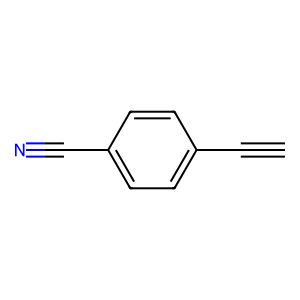

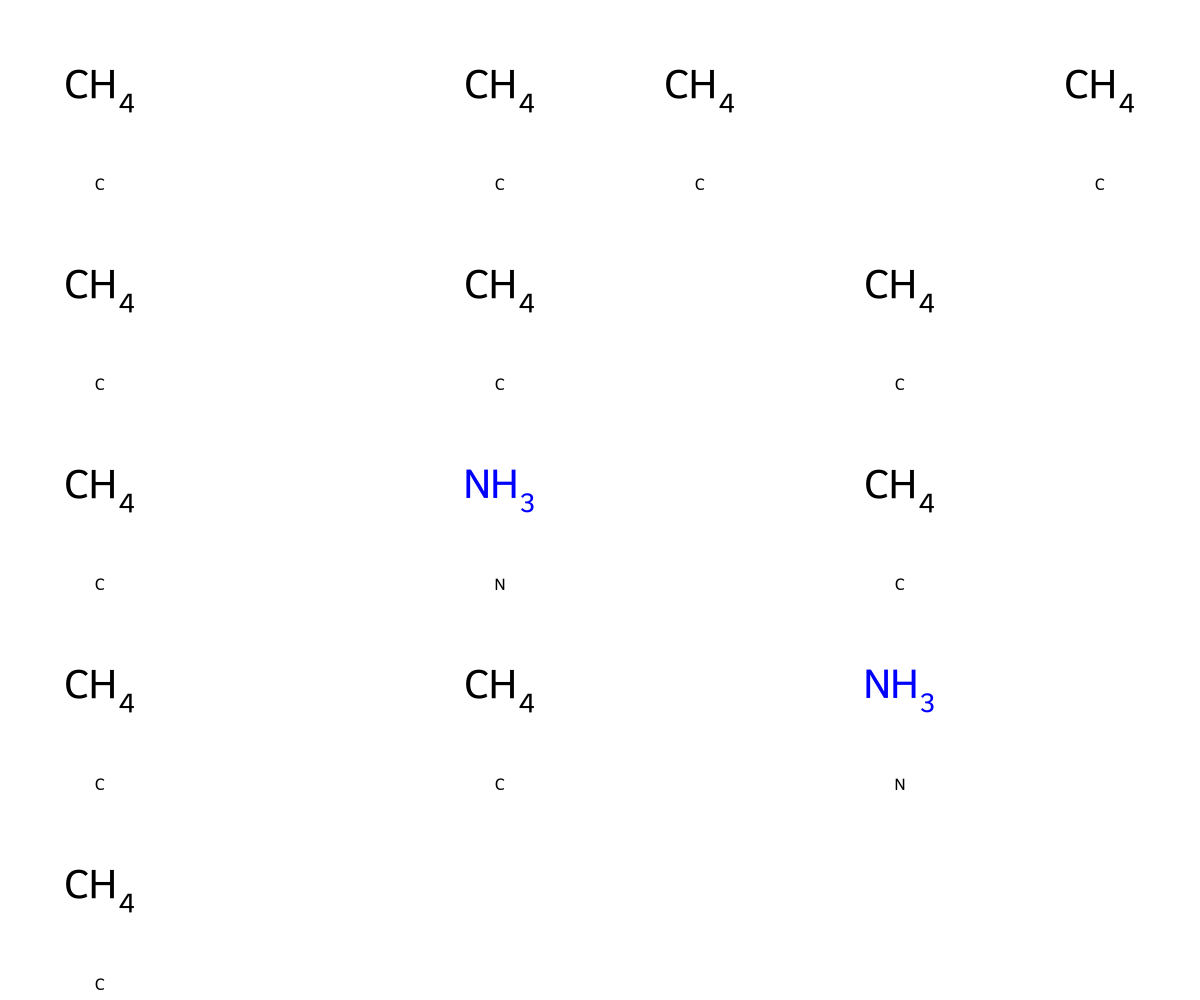

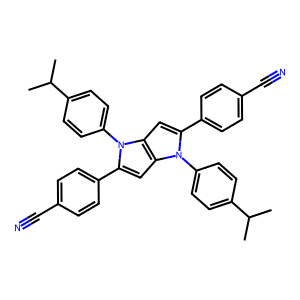

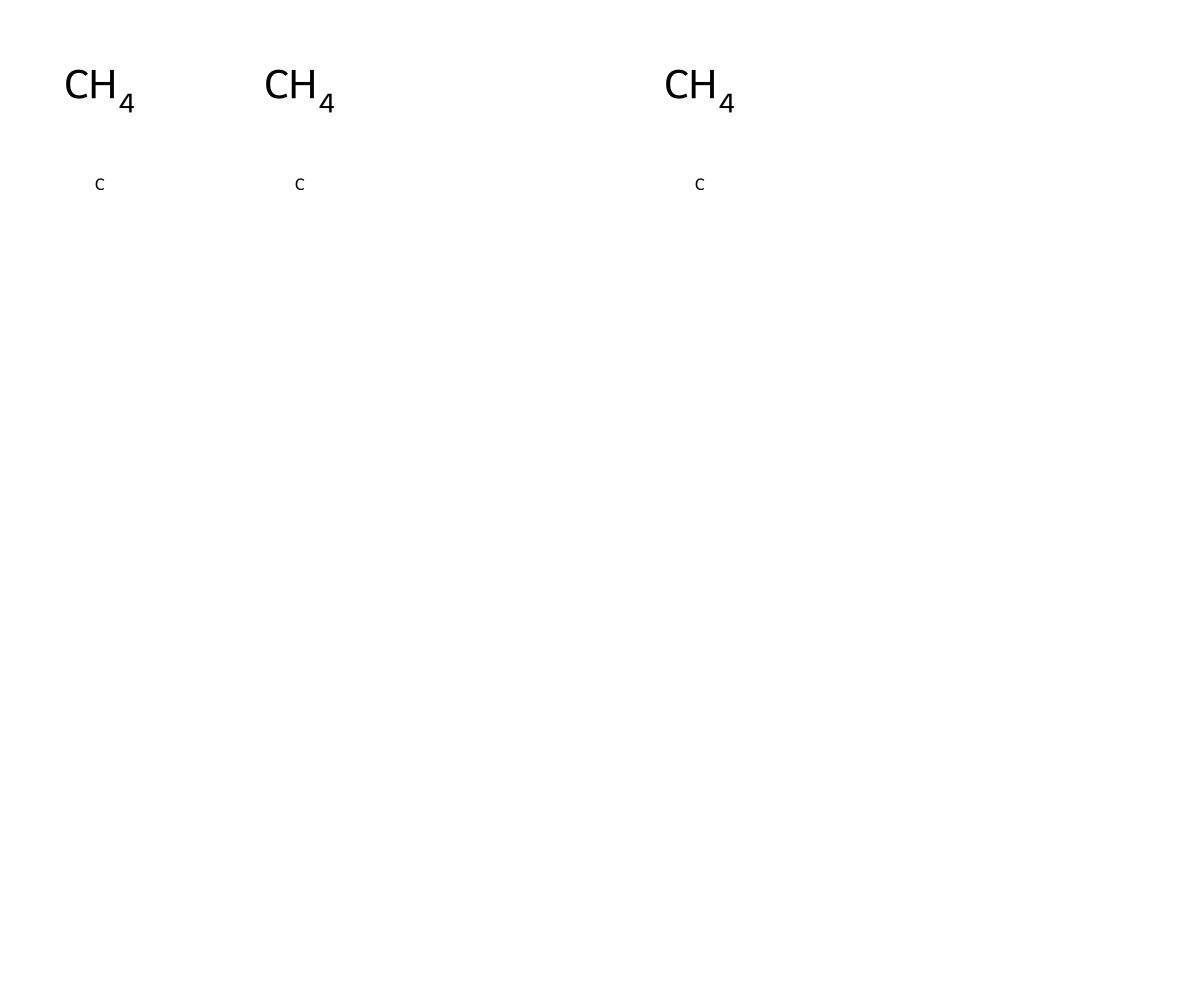

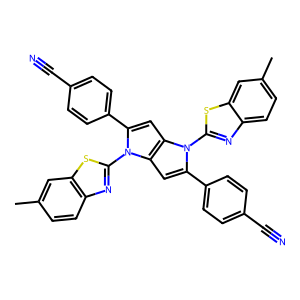

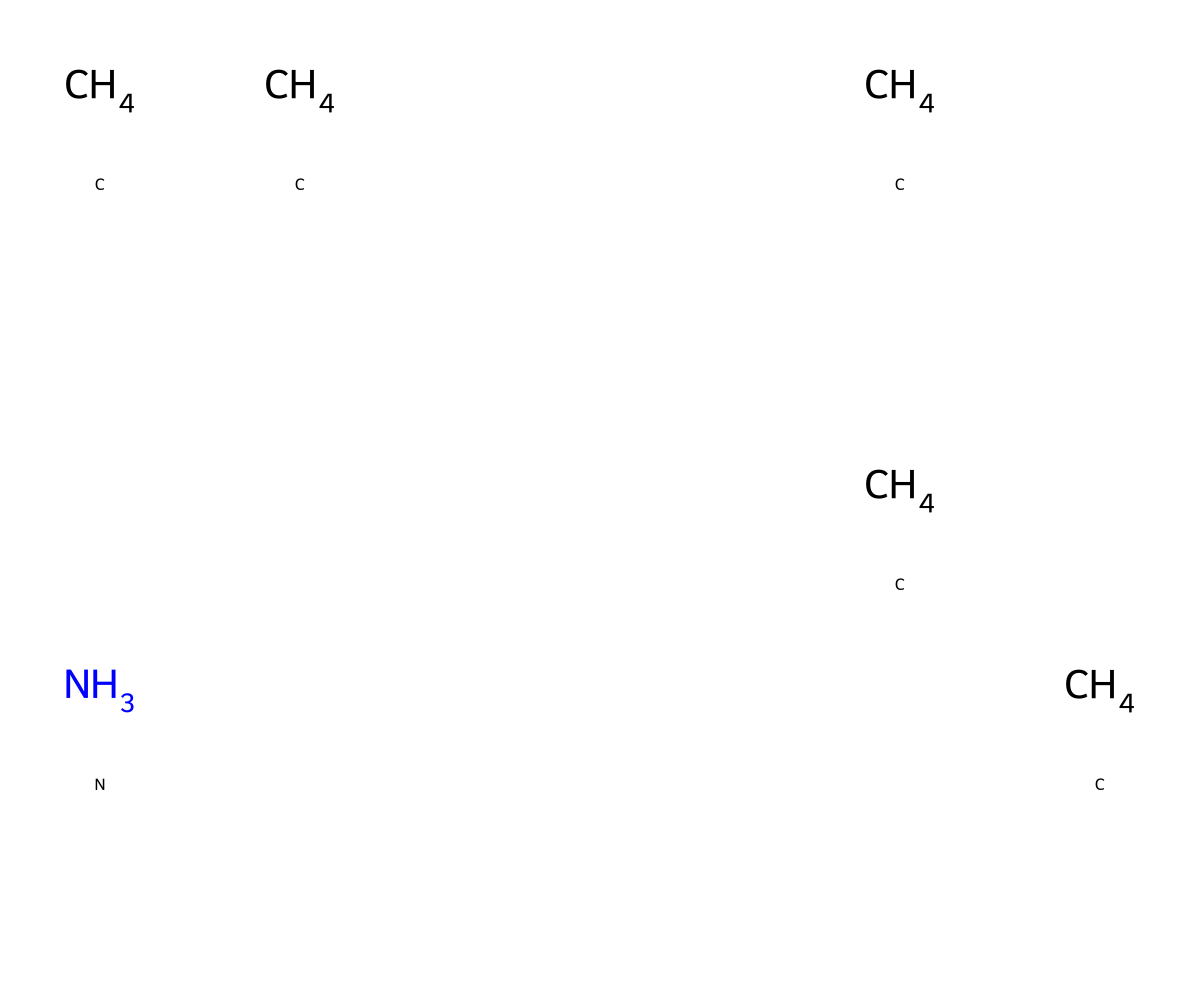

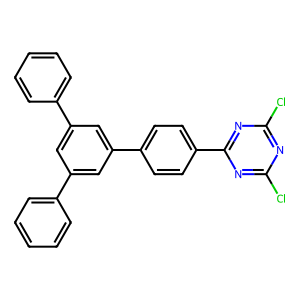

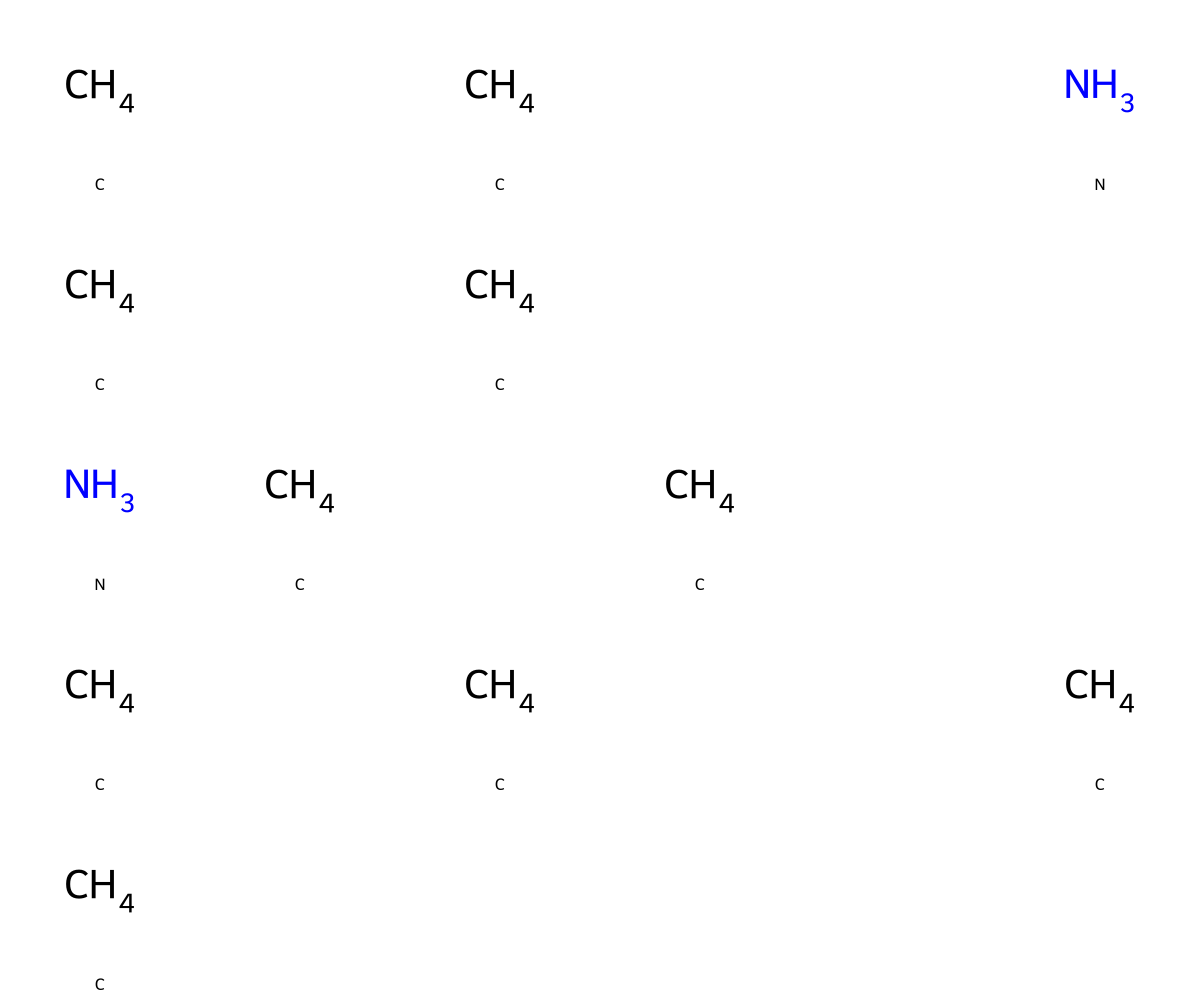

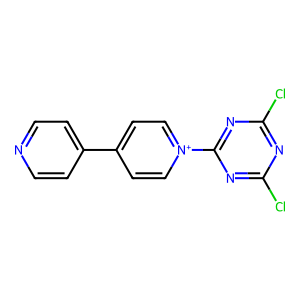

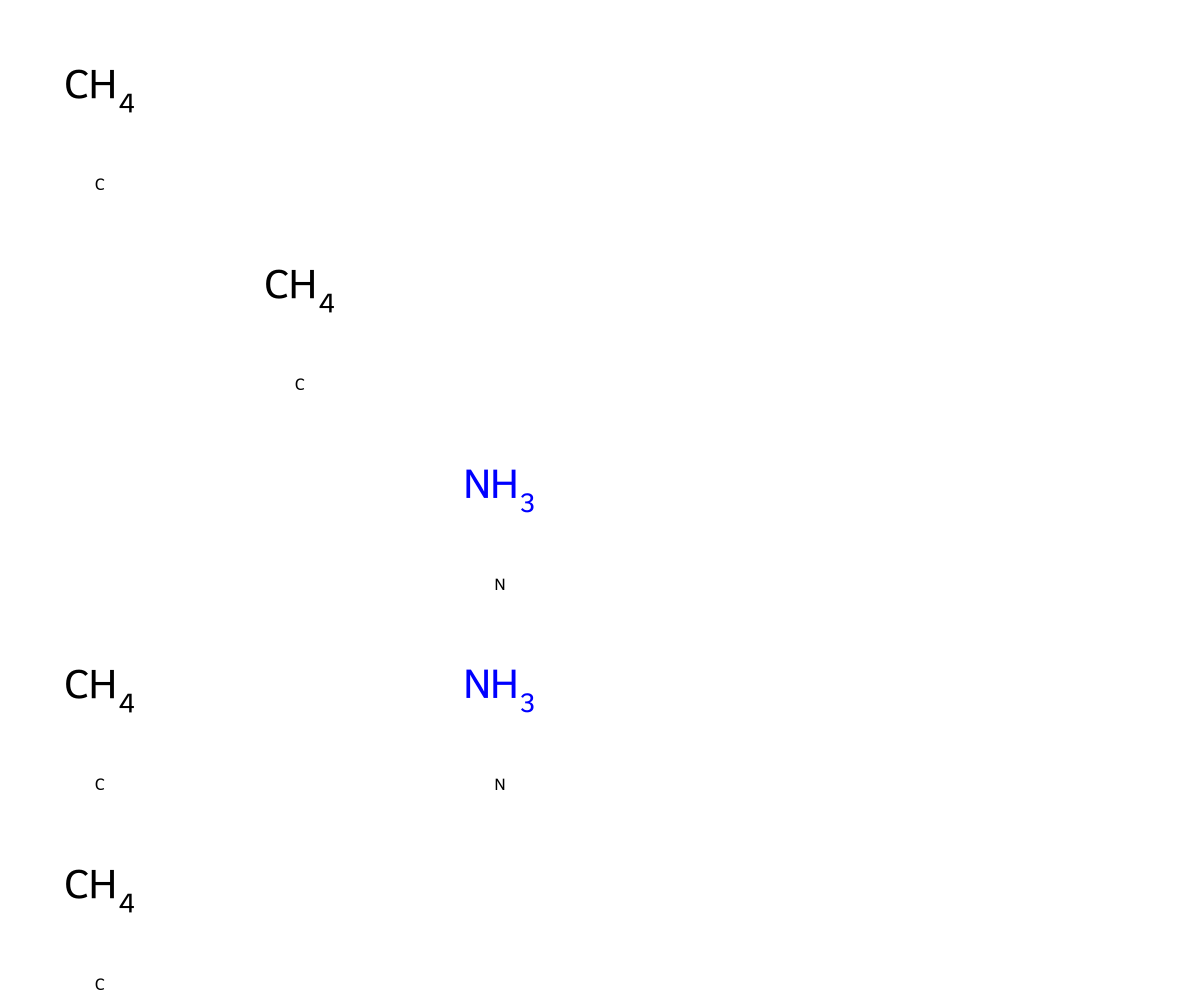

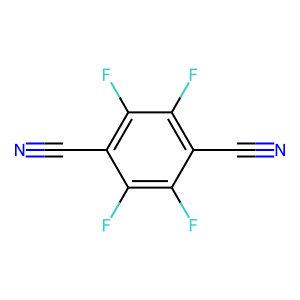

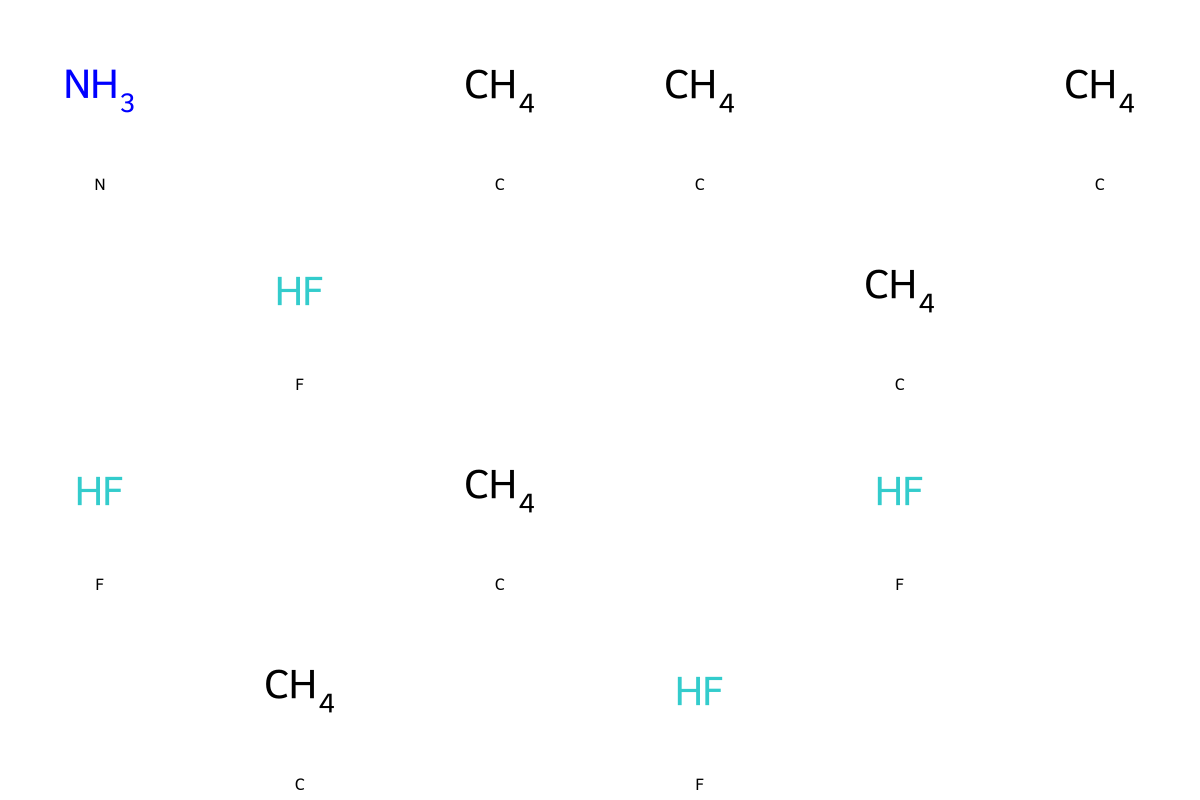

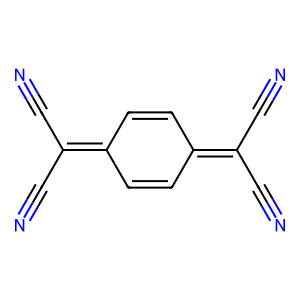

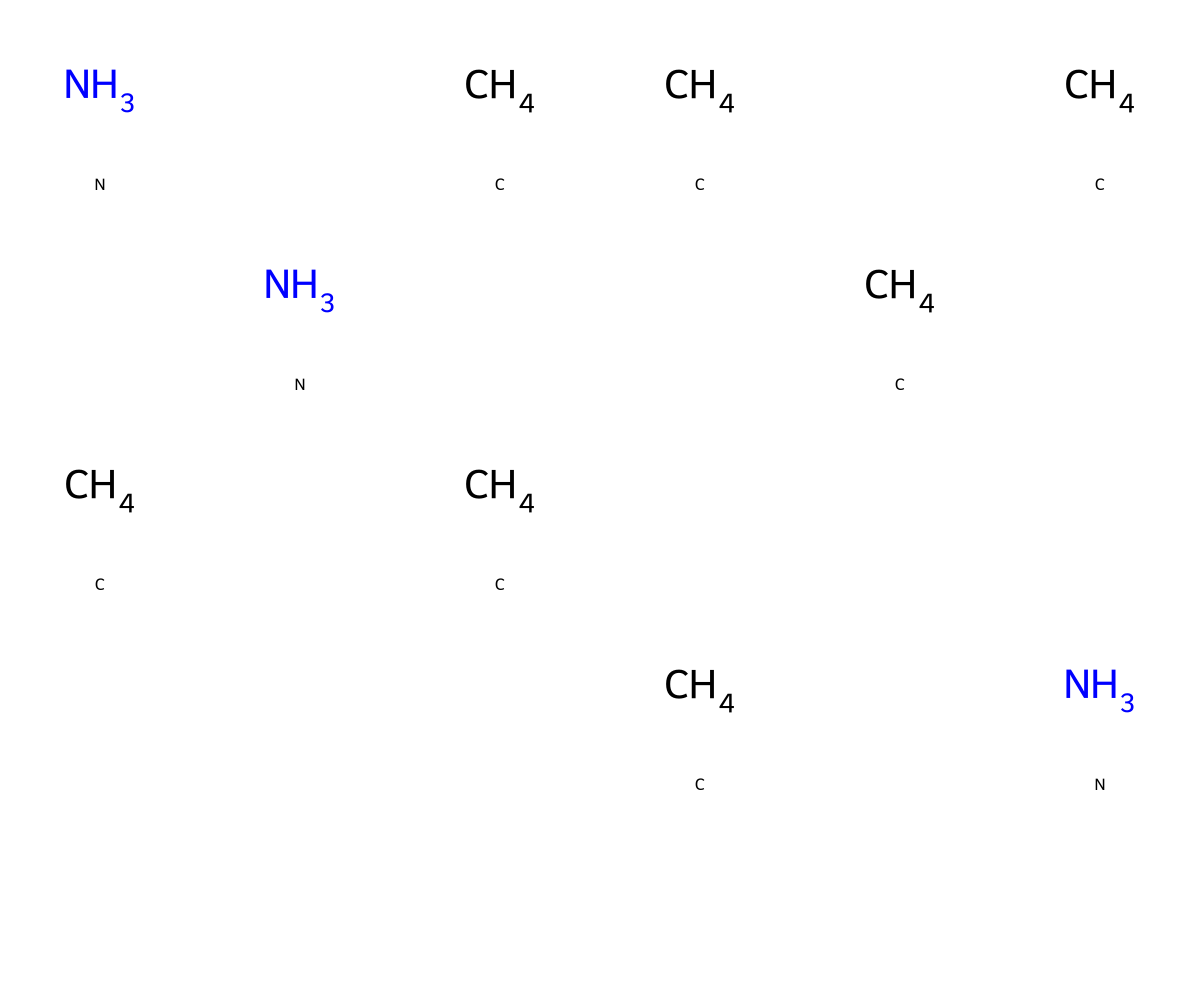

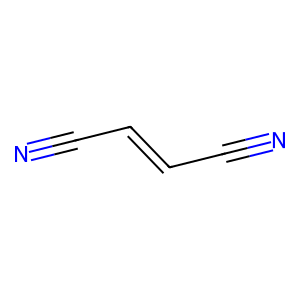

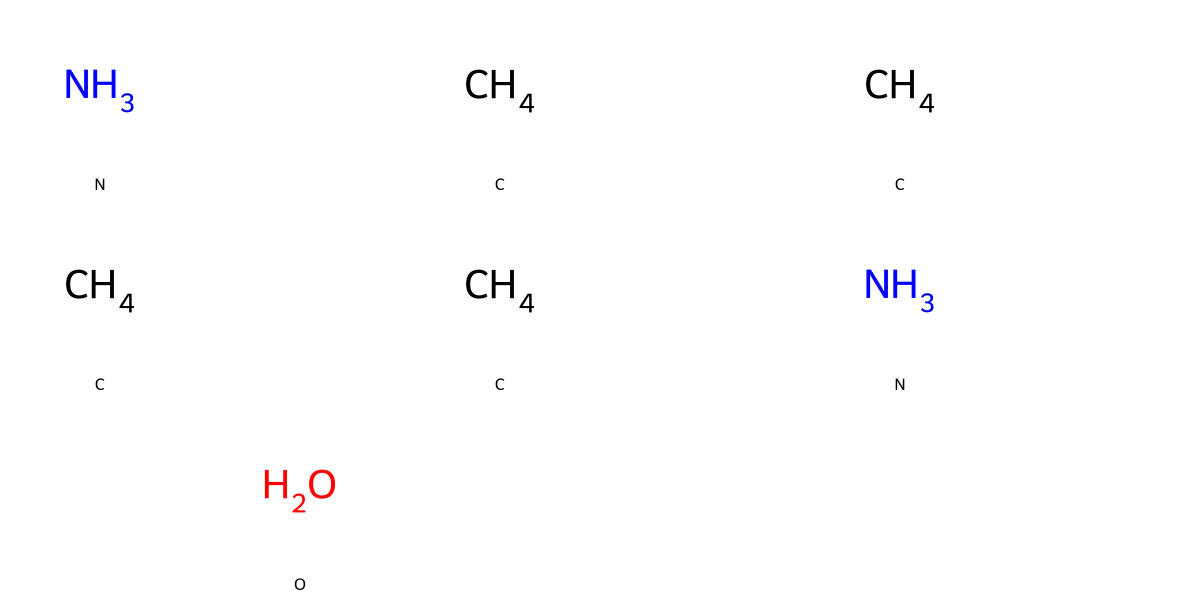

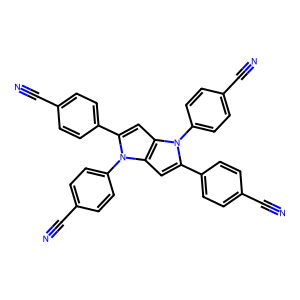

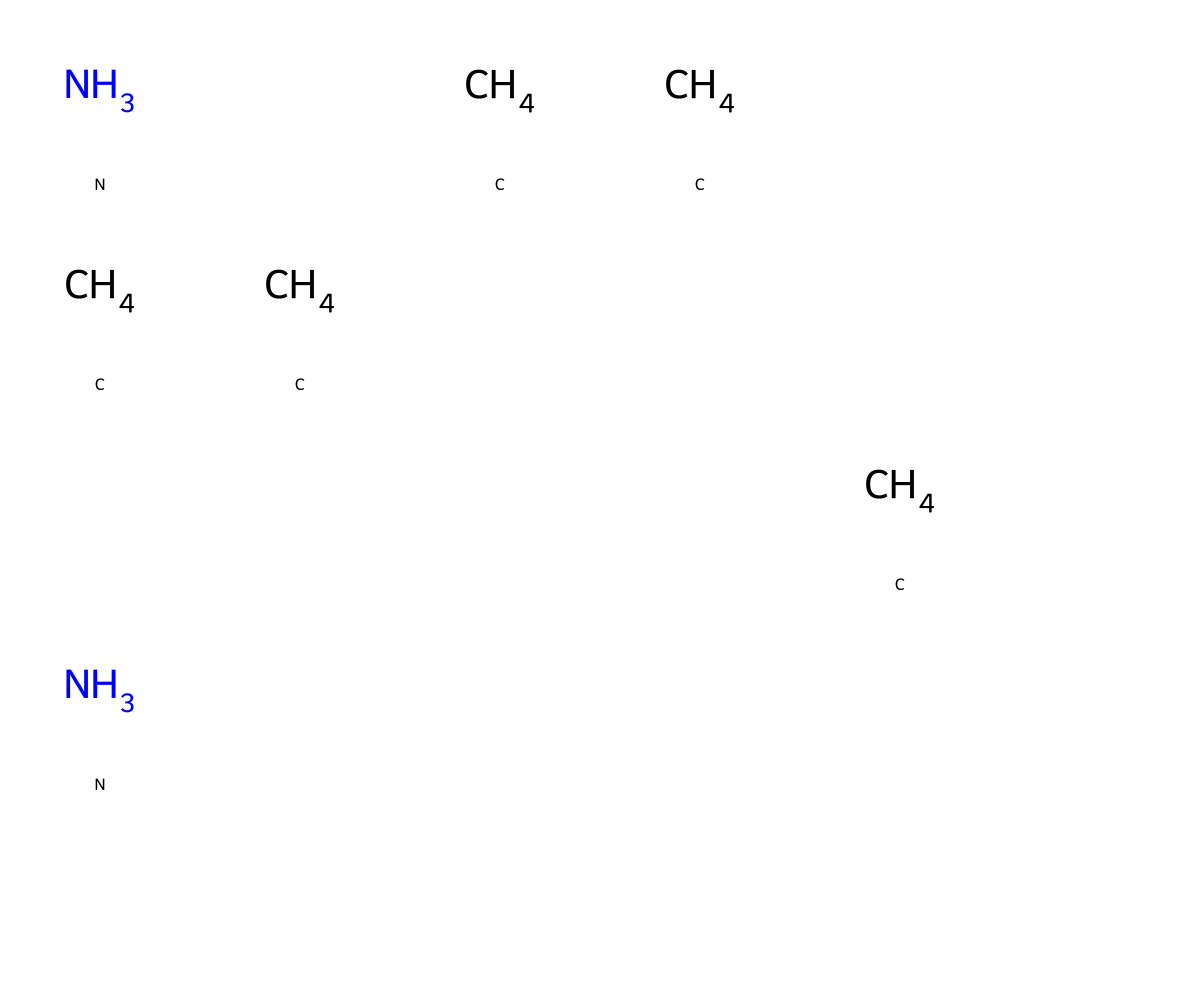

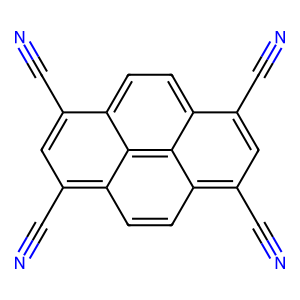

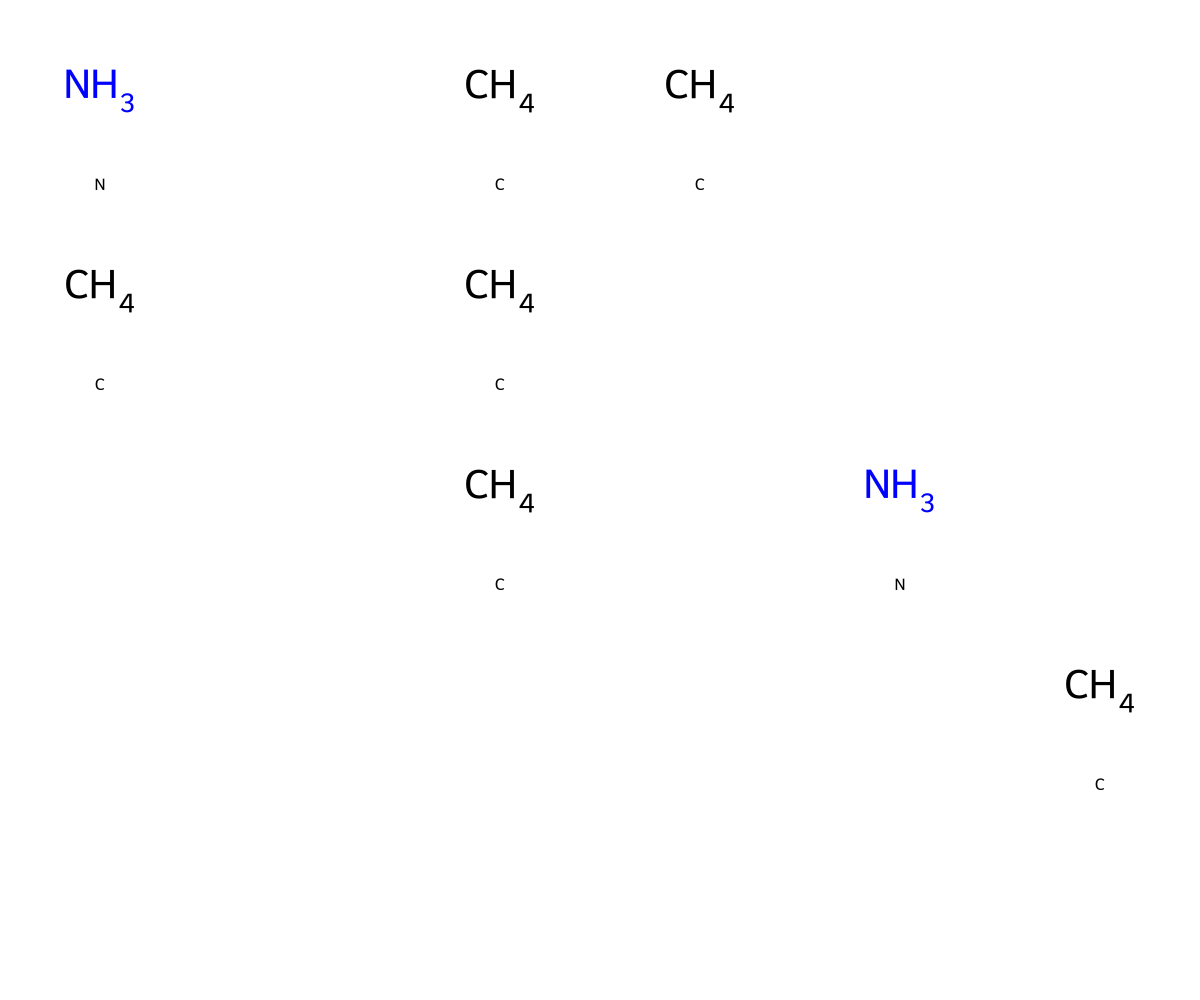

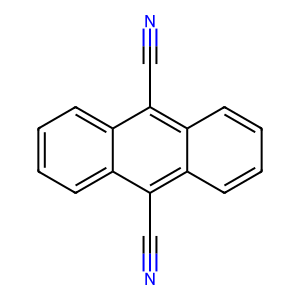

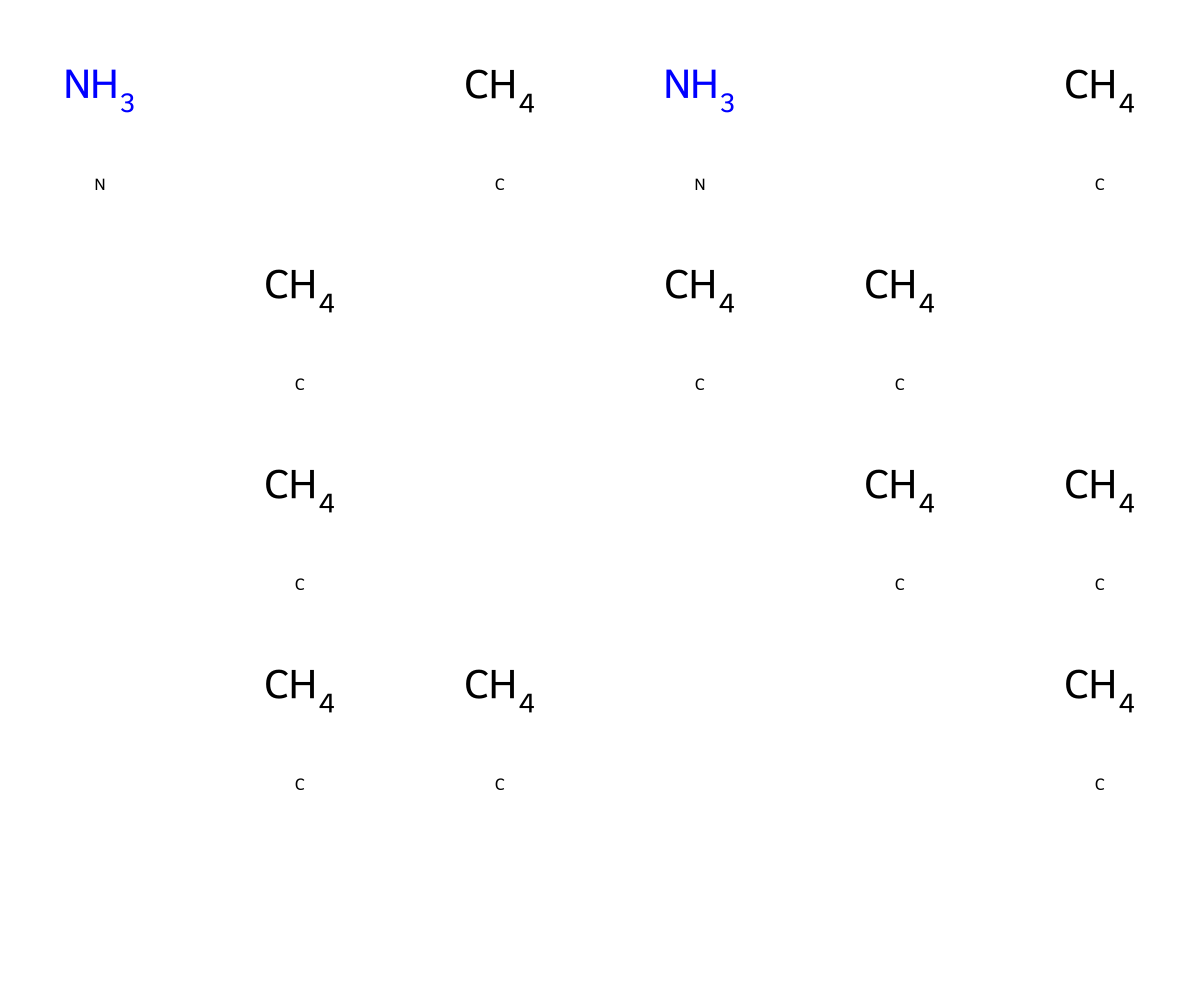

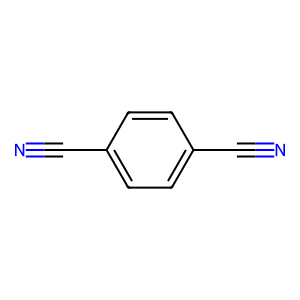

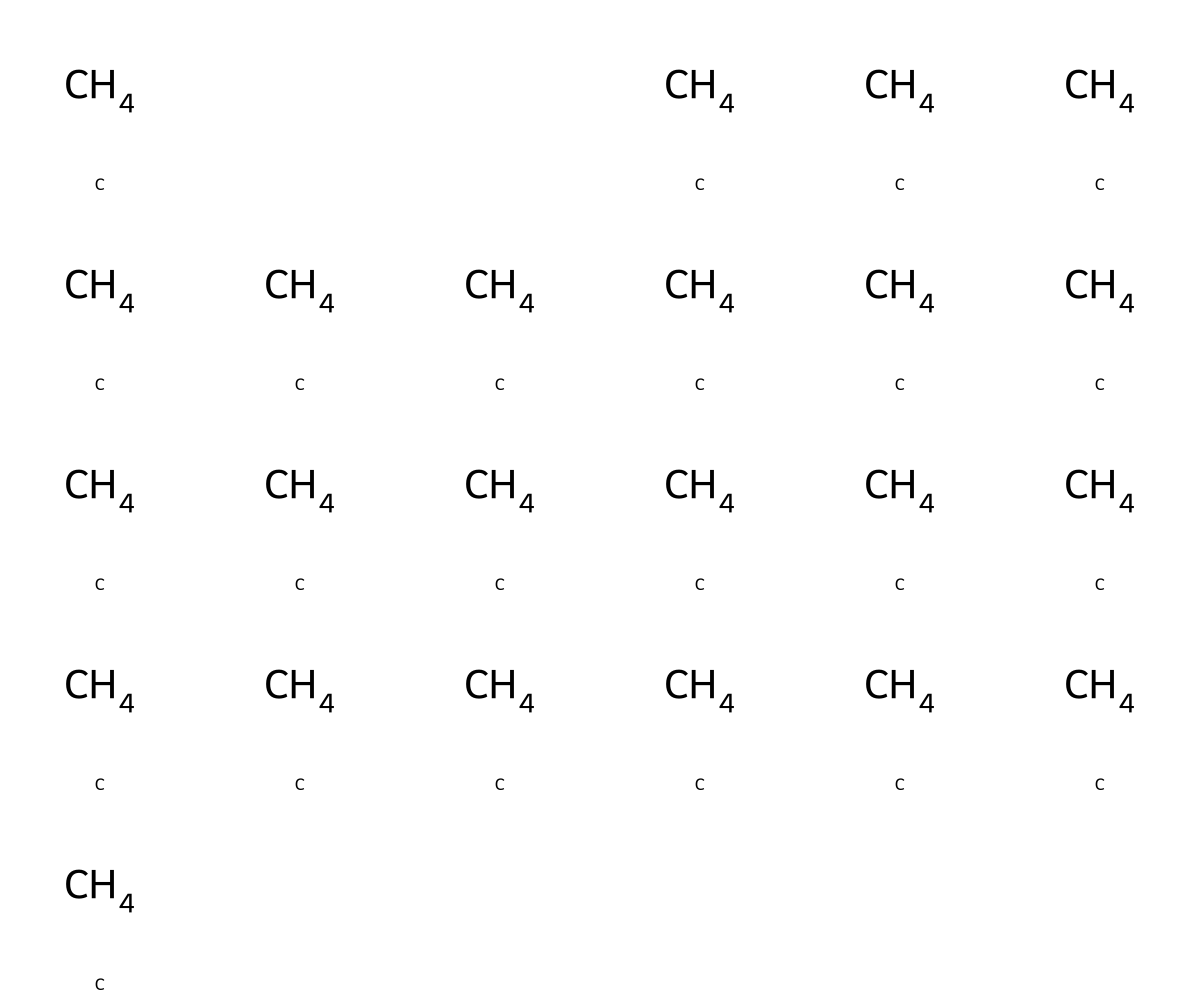

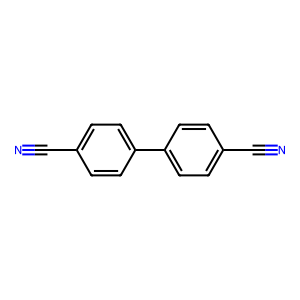

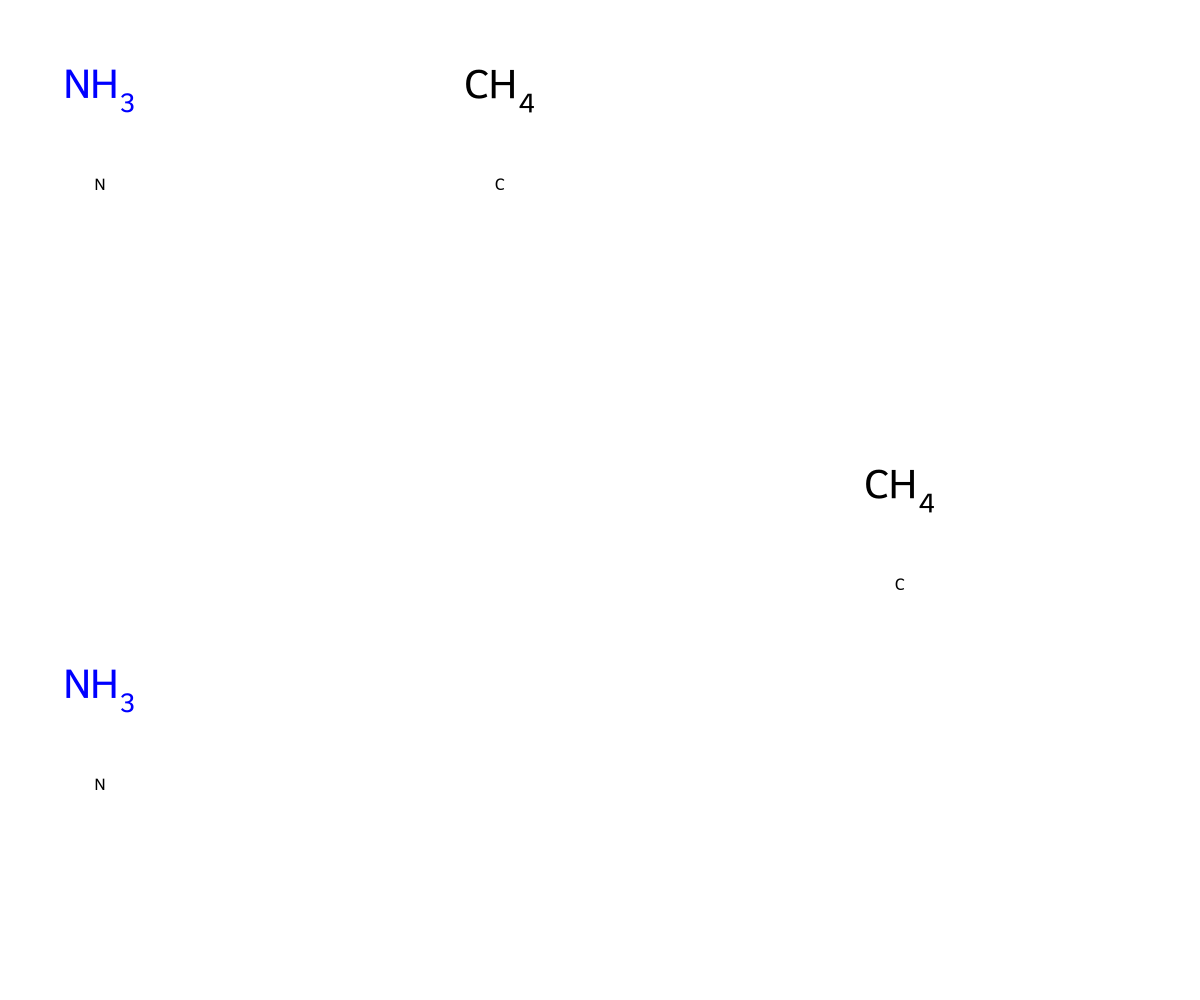

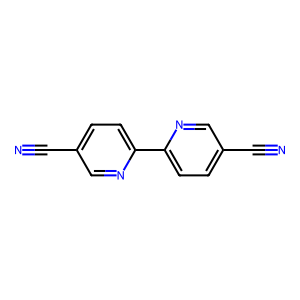

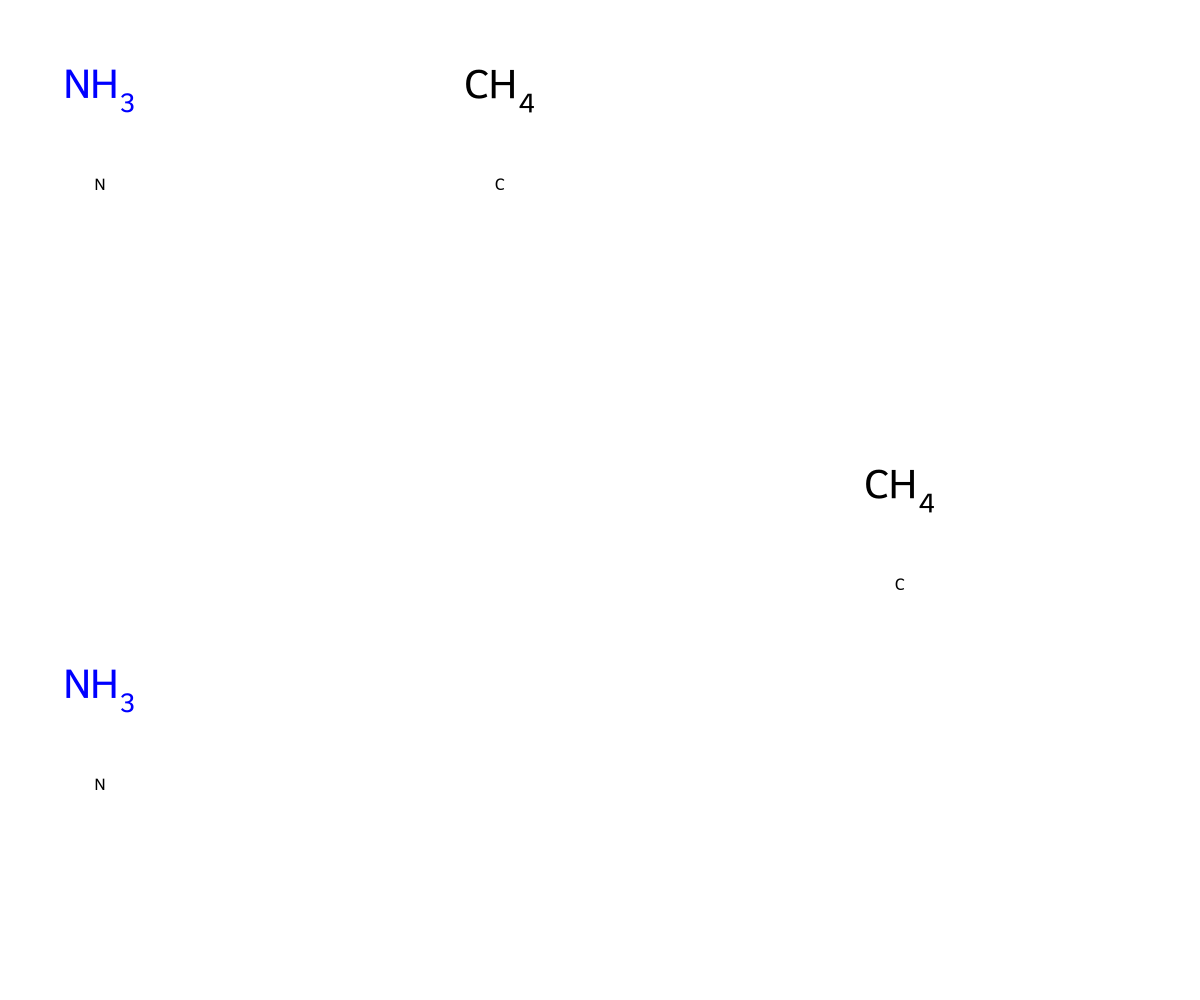

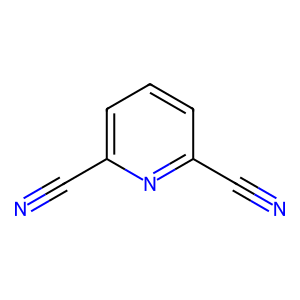

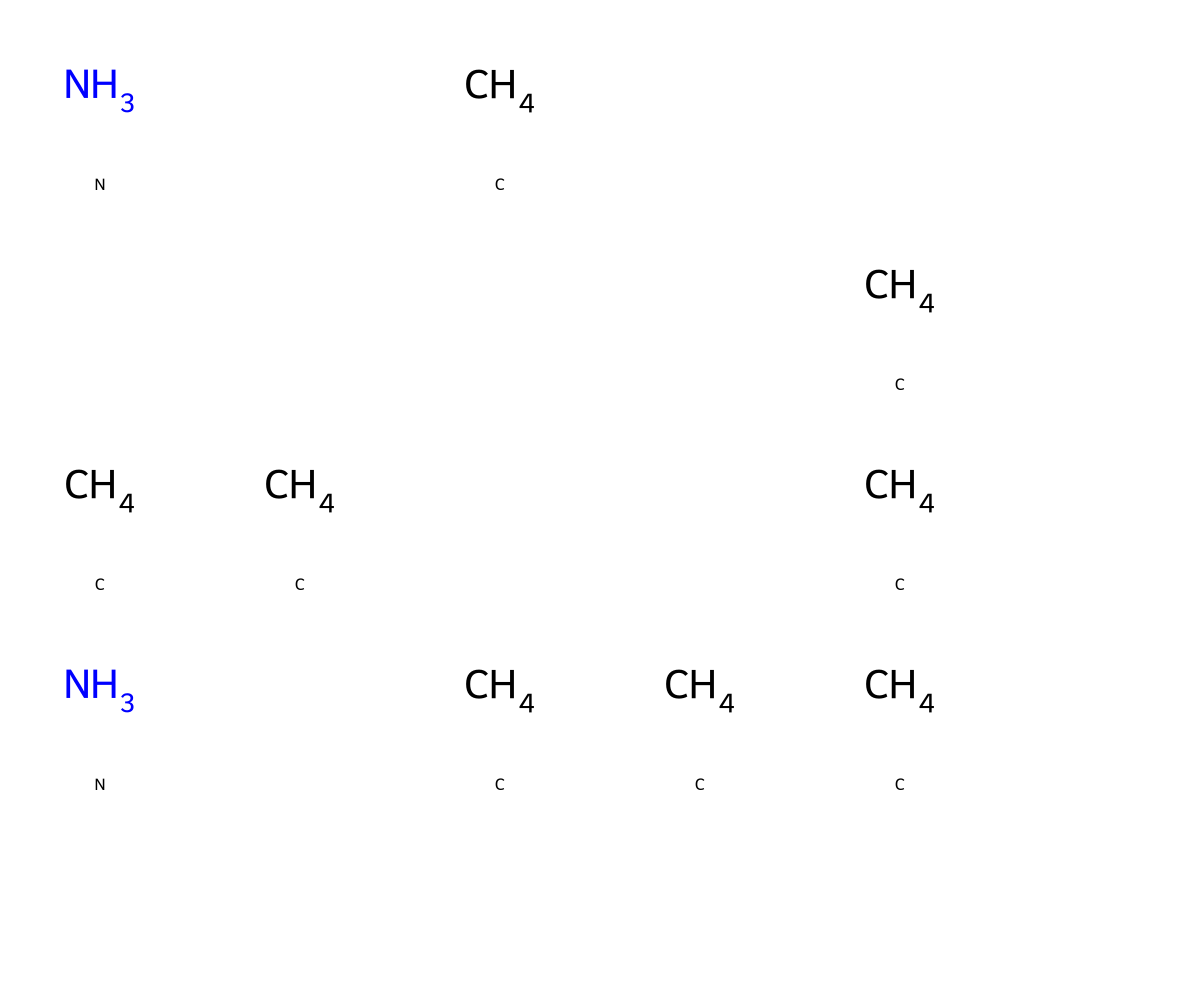

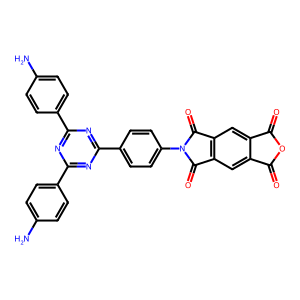

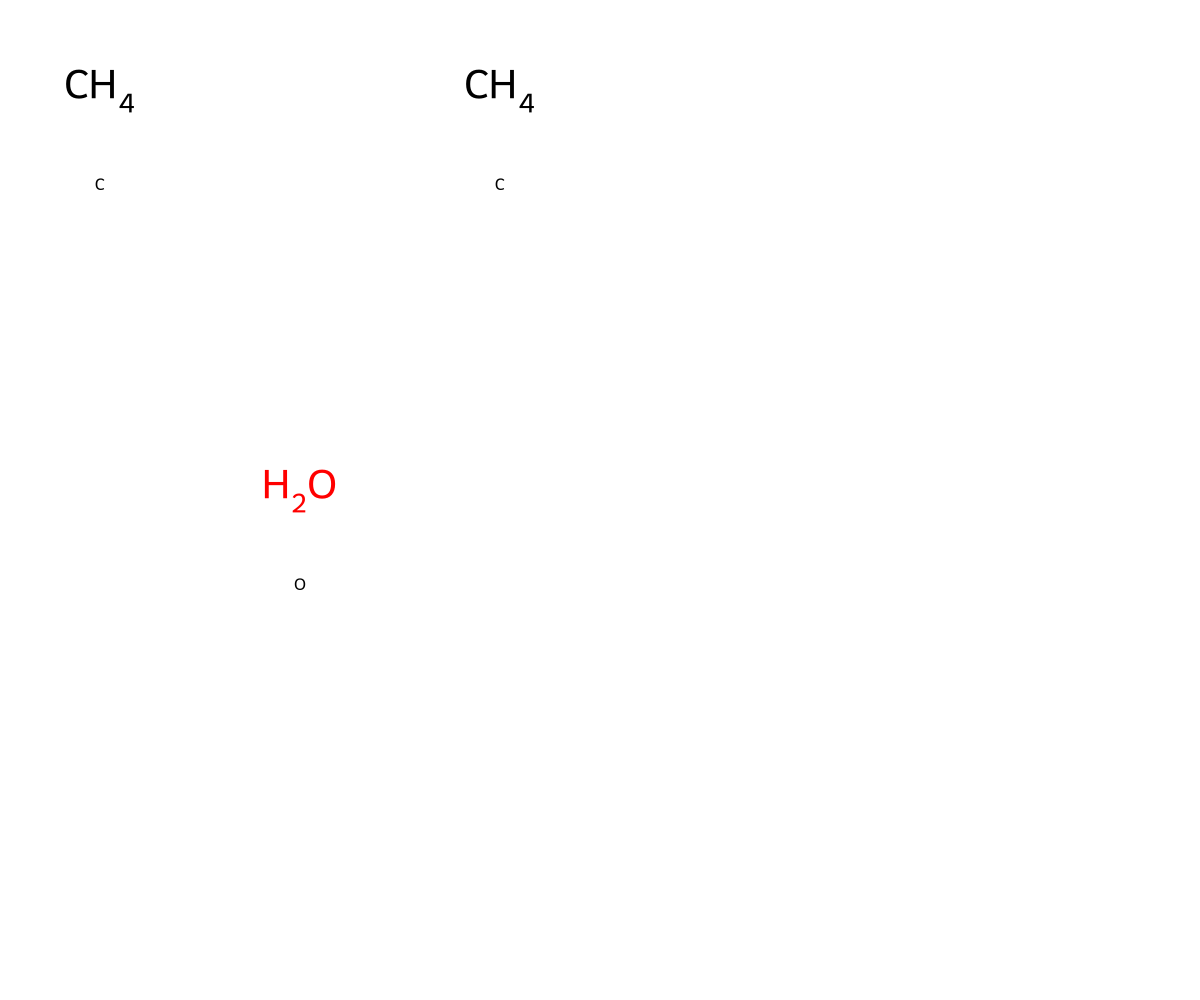

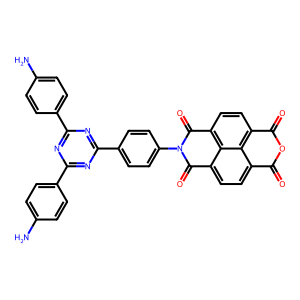

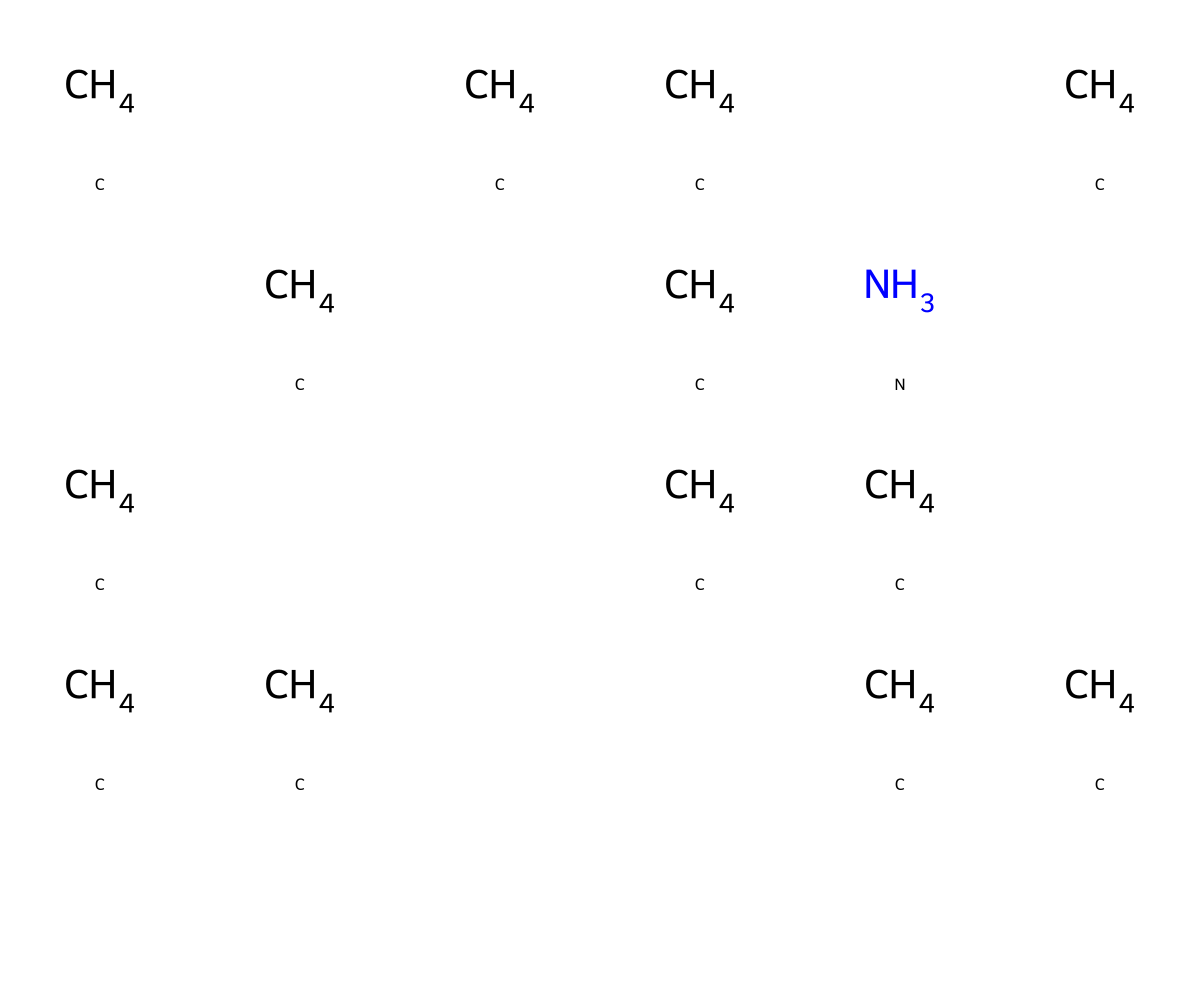

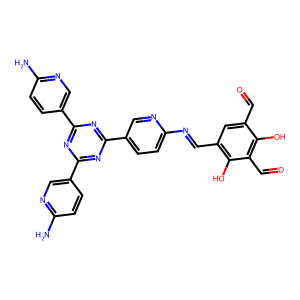

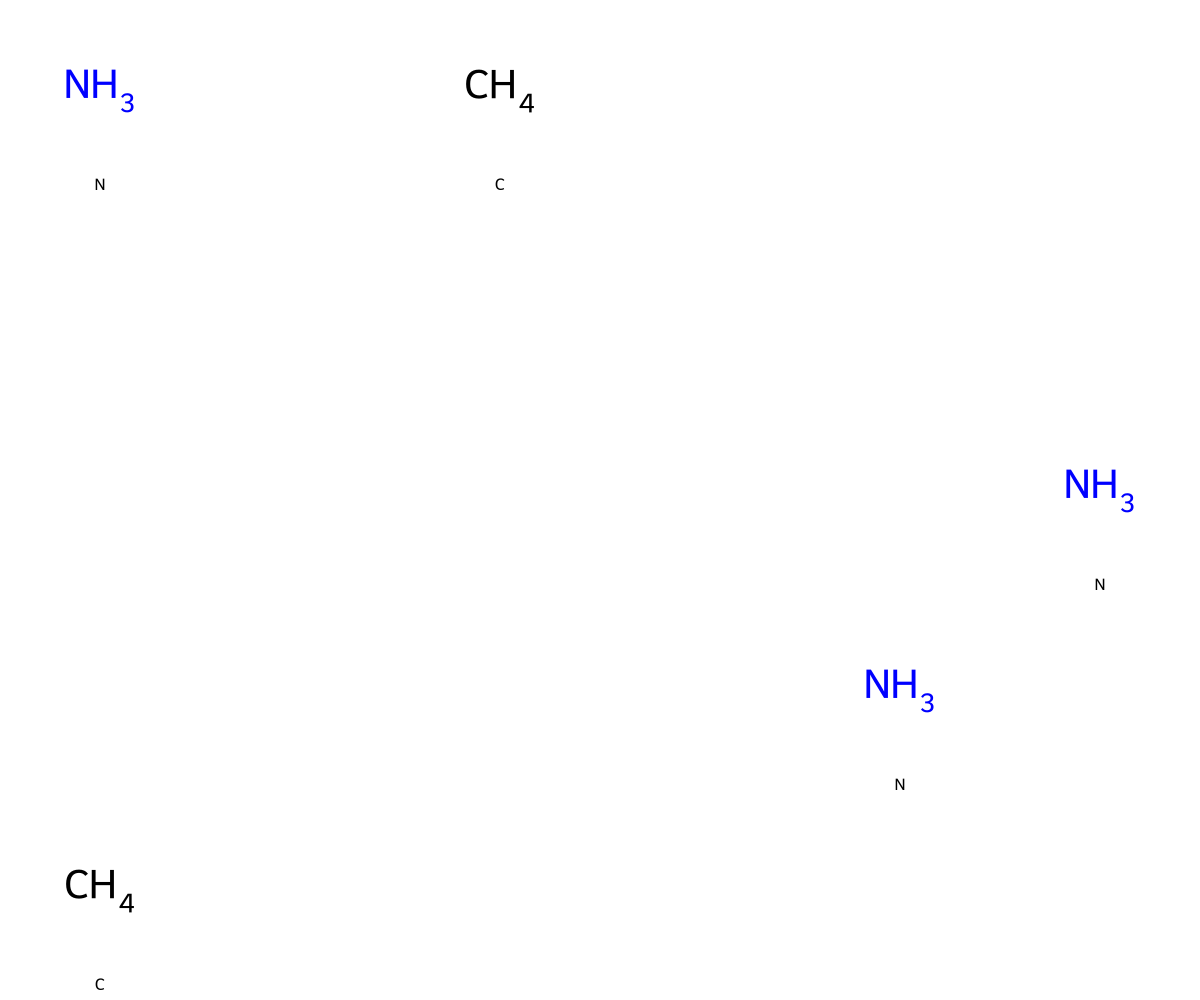

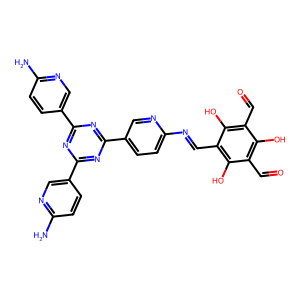

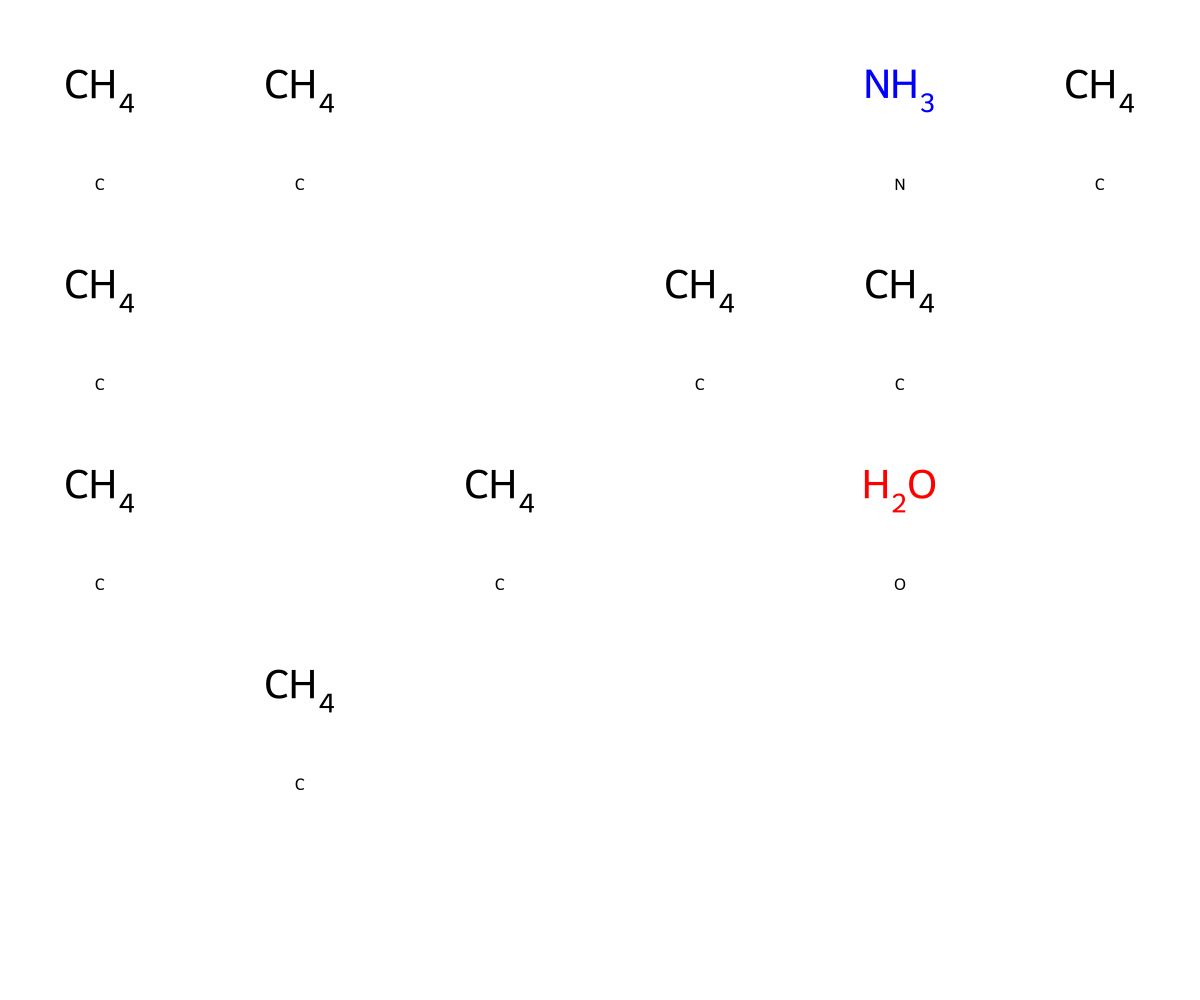

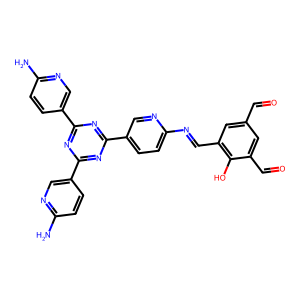

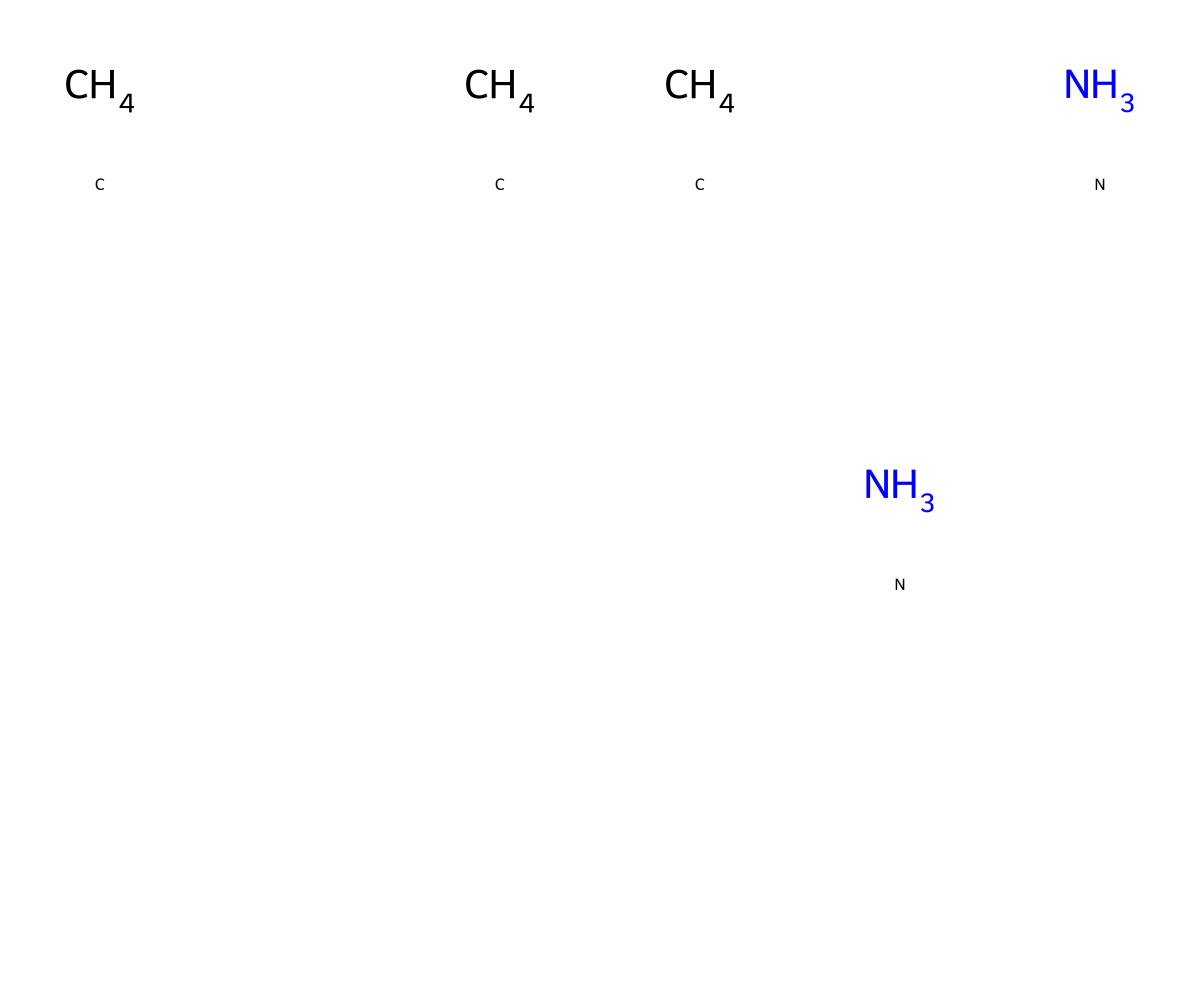

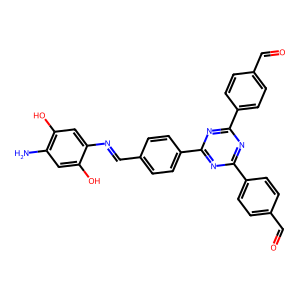

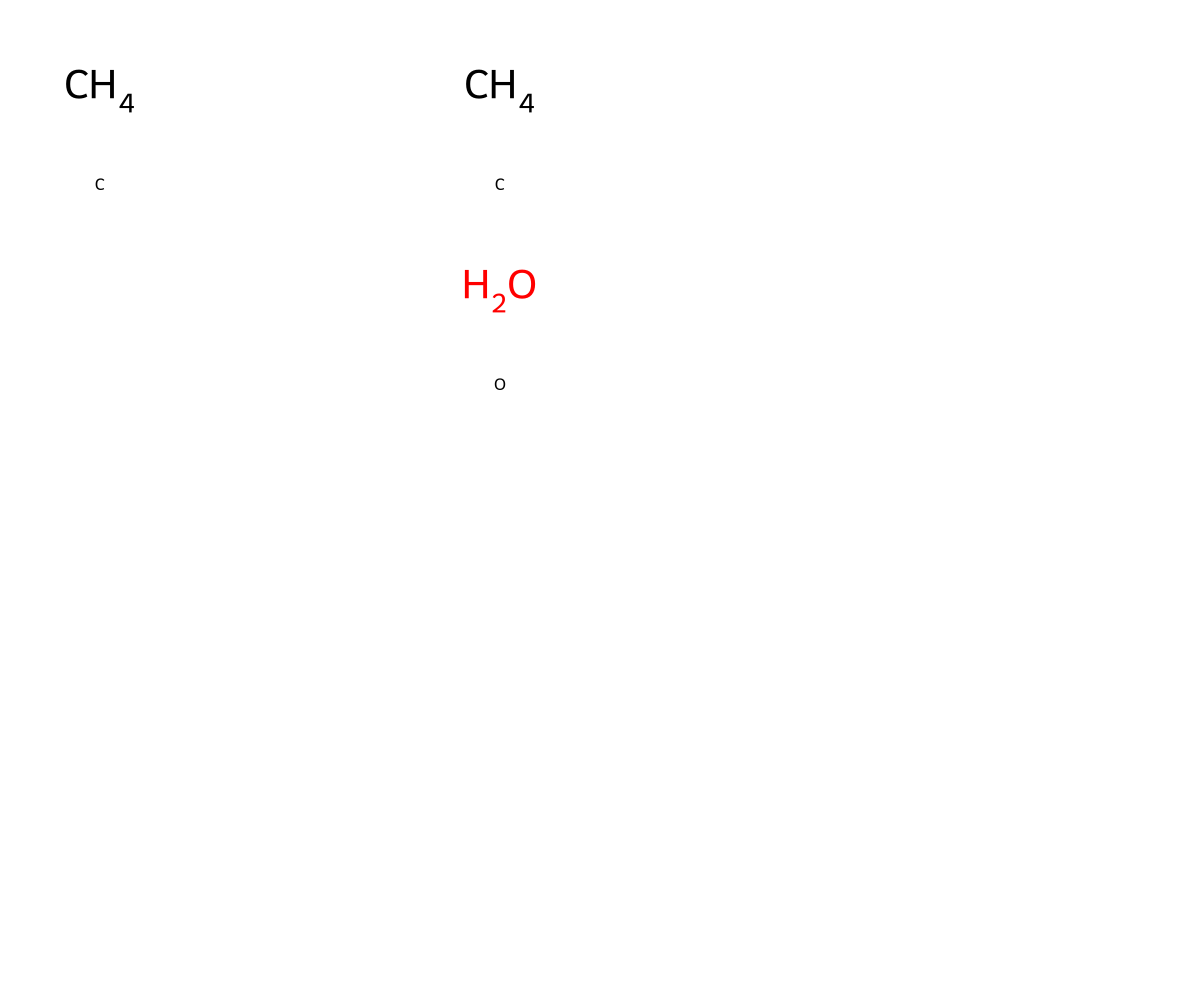

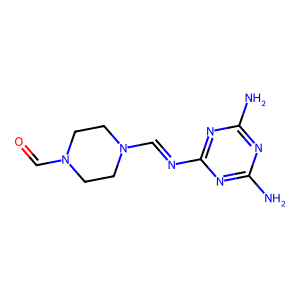

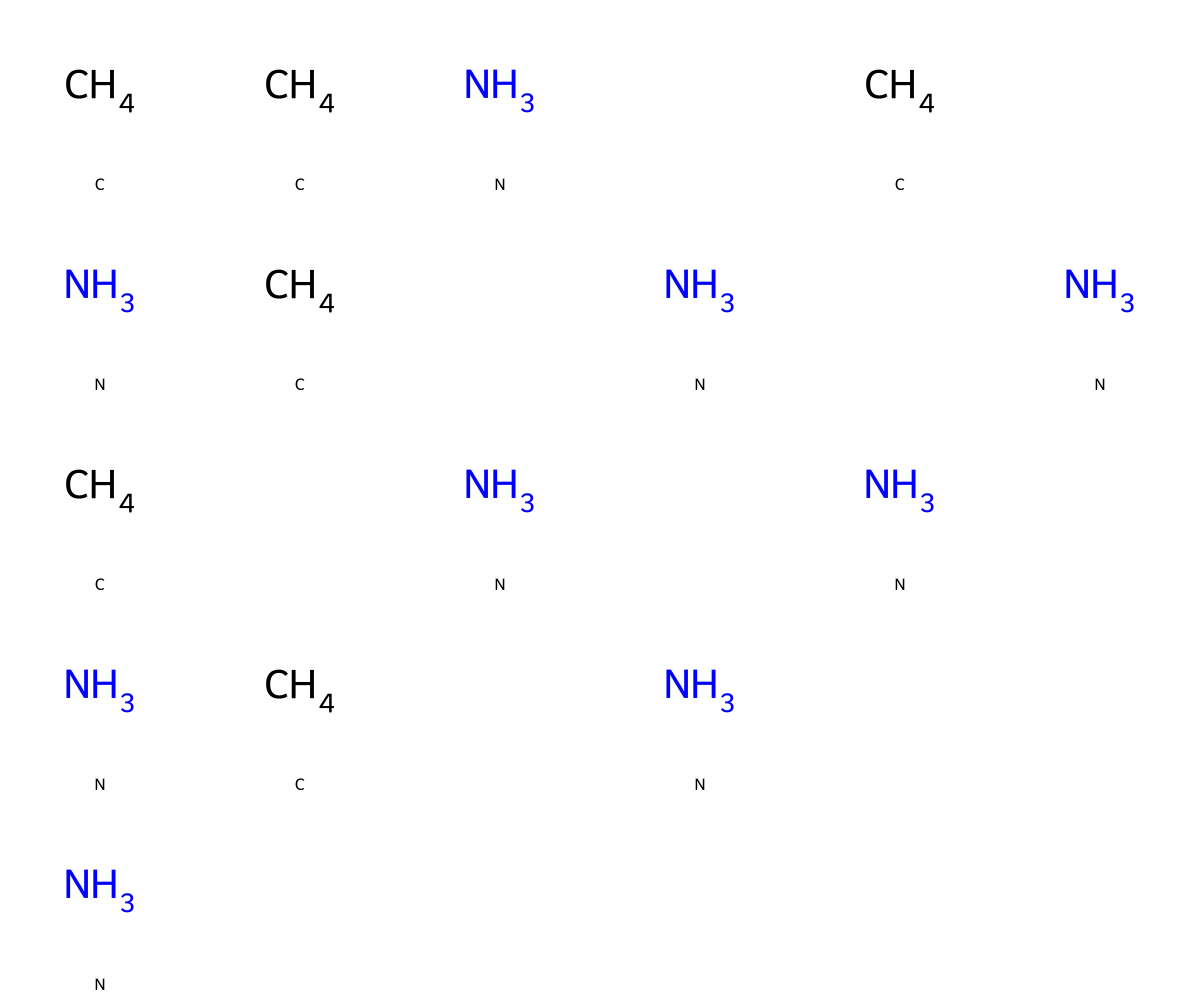

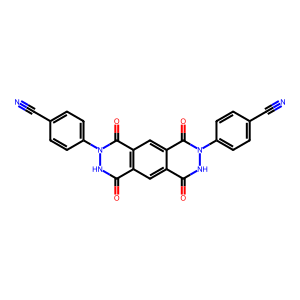

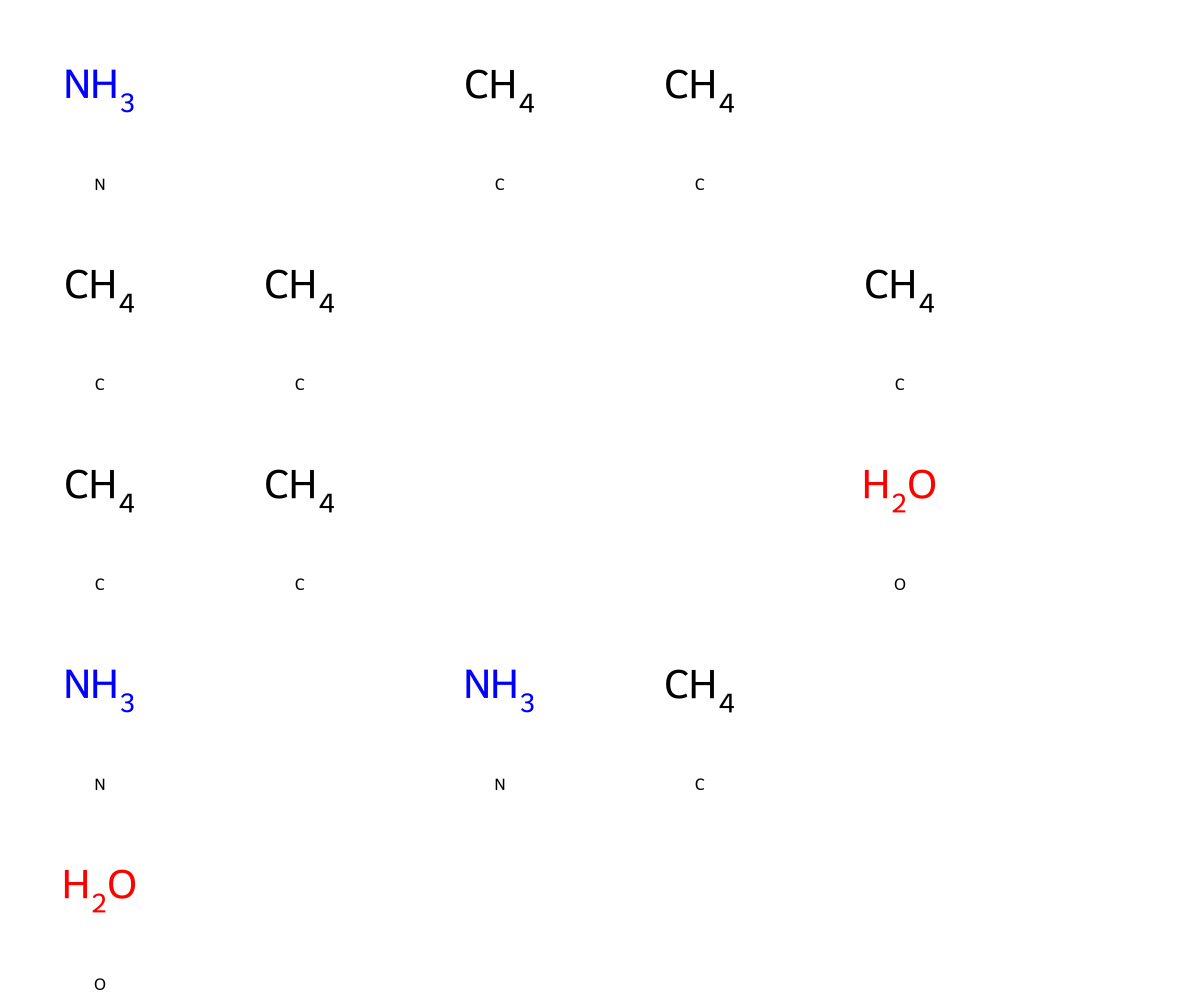

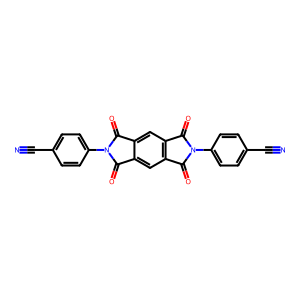

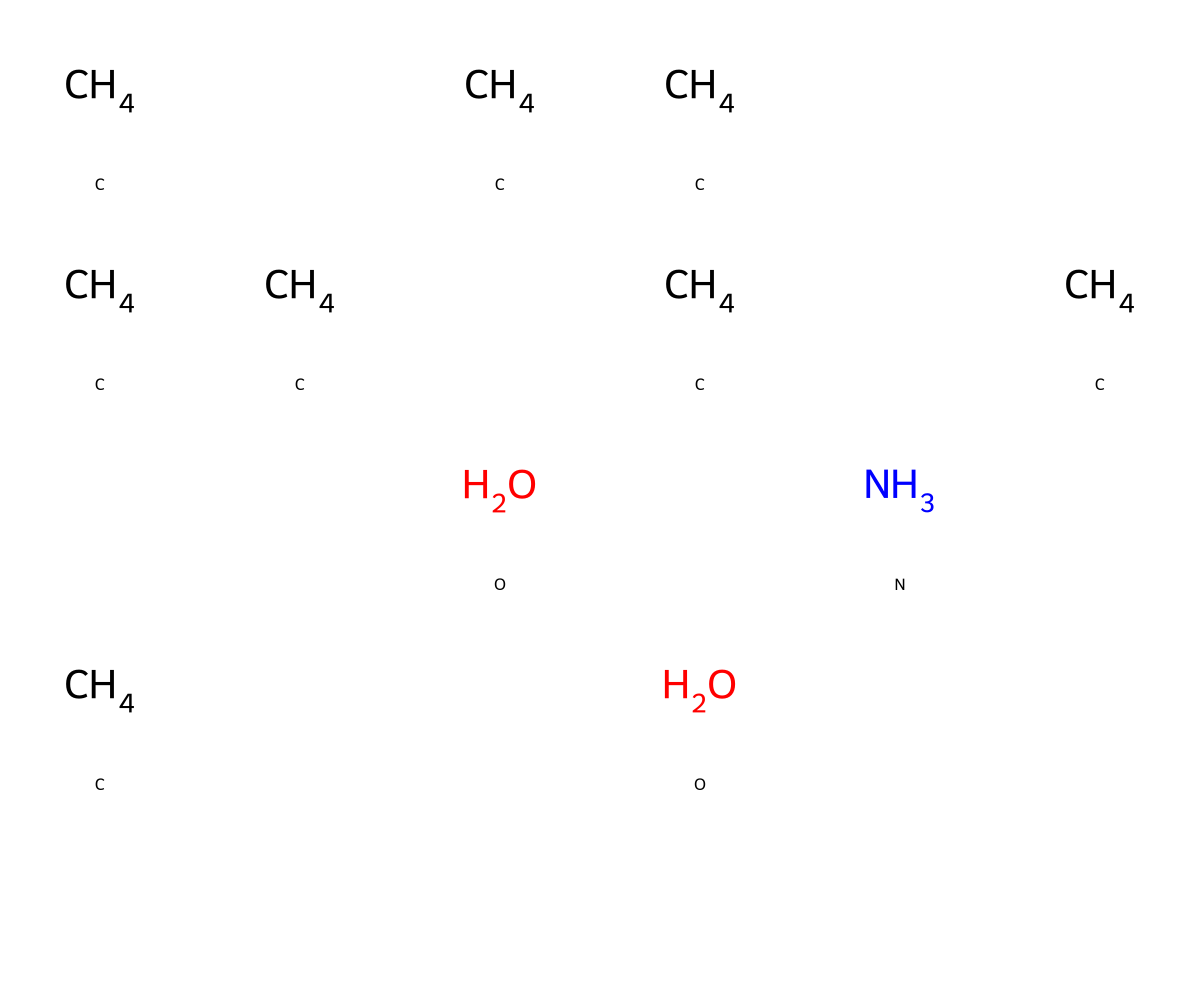

In [13]:
for ori_smis, gen_smis in zip(expert_smiles, gen_smis_lst):
    mol = Chem.MolFromSmiles(ori_smis)
    display(Draw.MolToImage(mol, legends=f"Original {ori_smis}"))
    gen_mols = [Chem.MolFromSmiles(smi) for smi in gen_smis[:25]] # limit the number of molecules to display
    display(Draw.MolsToGridImage(gen_mols, molsPerRow=6, legends=[smi for smi in gen_smis]))
    print("=====================================================================")
    print("\n")